<H1>IVAN RAYMOND M. AGUIWAS</H1>
<h4>BSIT-3C</h4>


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
import sklearn
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression

In [2]:
dengue = pd.read_csv("dengue.csv")

<h2>CHANGING DATA TYPES</h2>

In [3]:
dengue['Month'] = dengue ['Month'].astype("category")
dengue['Region'] = dengue ['Region'].astype("category")

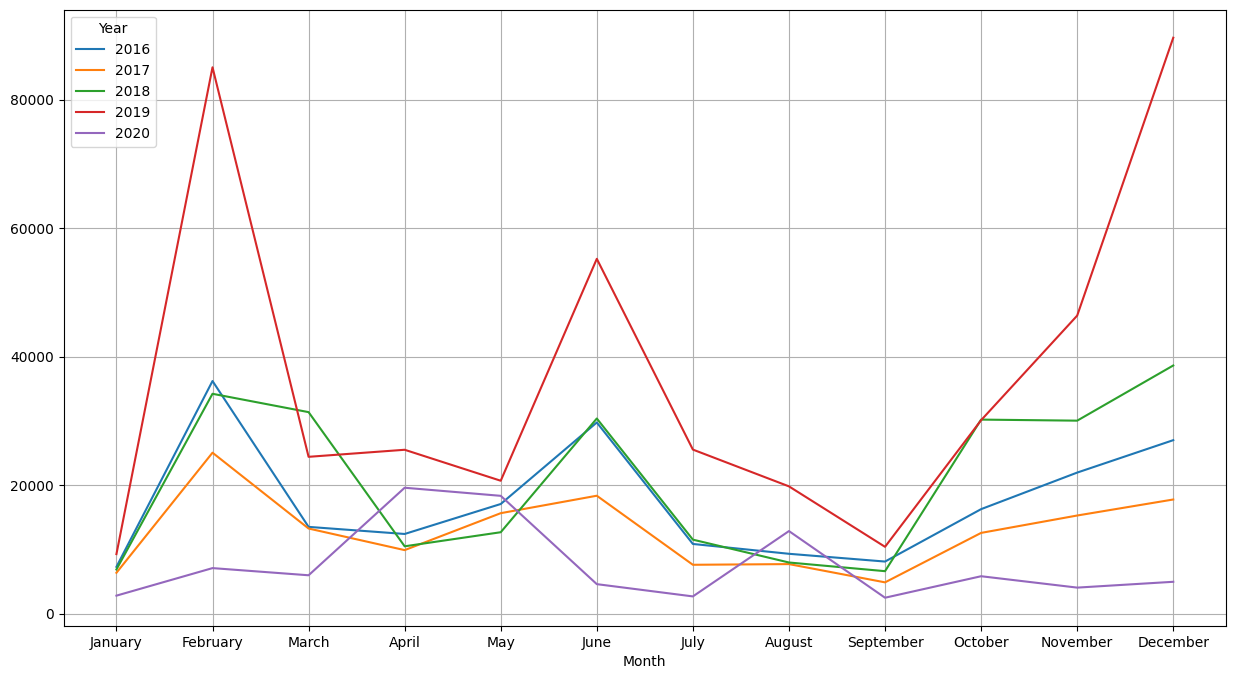

In [4]:
month = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_cases = dengue.groupby([dengue.Month, dengue.Year])["Dengue_Cases"].sum()
monthly_cases = monthly_cases.unstack().plot()
plt.gcf().set_size_inches(15,8)
plt.grid(True)
plt.xticks(range(0,12), month)
plt.show()

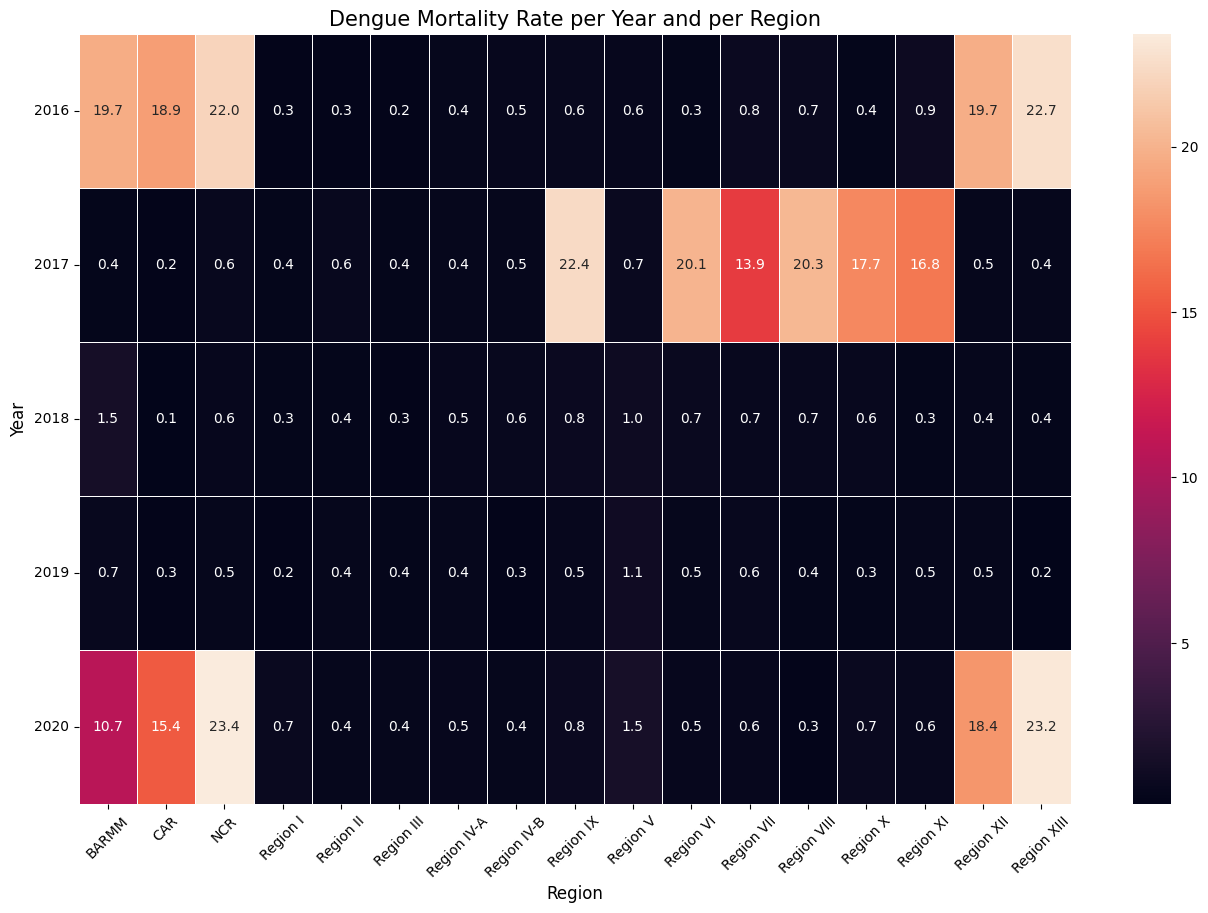

In [5]:
dengue["Mortality Rate"] = (dengue['Dengue_Deaths'] / dengue['Dengue_Cases']) * 100
heatmap = dengue.groupby(['Year', 'Region']) ['Mortality Rate'].mean().unstack()

plt.figure(figsize=(16,10))
sns.heatmap(heatmap, annot = True, fmt= '.1f', linewidth = .5)
plt.title('Dengue Mortality Rate per Year and per Region', fontsize =15)
plt.xlabel('Region', fontsize = 12)
plt.ylabel('Year', fontsize = 12)
plt.xticks(rotation = 45)
plt.yticks(rotation = 0)
plt.show()

In [6]:
dengue['Month'] = dengue['Month'].astype('str')

In [7]:
# Combine Month and Year into a Date column
dengue['Date'] = pd.to_datetime(dengue['Month'] + ' ' + dengue['Year'].astype(str))

# Optional: sort by date
dengue = dengue.sort_values('Date')

In [8]:
region4_df = dengue[dengue['Region'] == 'Region IV-A']
monthly_cases = region4_df.groupby('Date')['Dengue_Cases'].sum().reset_index()

In [9]:
monthly_cases

,Date,Dengue_Cases
0,2016-01-01,2993
1,2016-02-01,2035
2,2016-03-01,1327
3,2016-04-01,838
4,2016-05-01,714
5,2016-06-01,778
6,2016-07-01,2270
7,2016-08-01,3218
8,2016-09-01,3454
9,2016-10-01,3175


In [10]:
monthly_cases['Date_Ordinal'] = monthly_cases['Date'].map(lambda x: x.toordinal())

# monthly_cases['Date_Ordinal'] = monthly_cases['Date'].map(pd.Timestamp.toordinal)

# # # Reshape for sklearn
X = monthly_cases['Date_Ordinal'].values.reshape(-1, 1)
y = monthly_cases['Dengue_Cases'].values

# # # Fit model
model = LinearRegression()
model.fit(X, y)

# # # Predict
monthly_cases['Predicted_Cases'] = model.predict(X)

# # # Evaluate: R-squared
r_squared = model.score(X, y)
print(f"The model explains {r_squared:.1%} of the variation in dengue cases.")

The model explains 1.7% of the variation in dengue cases.


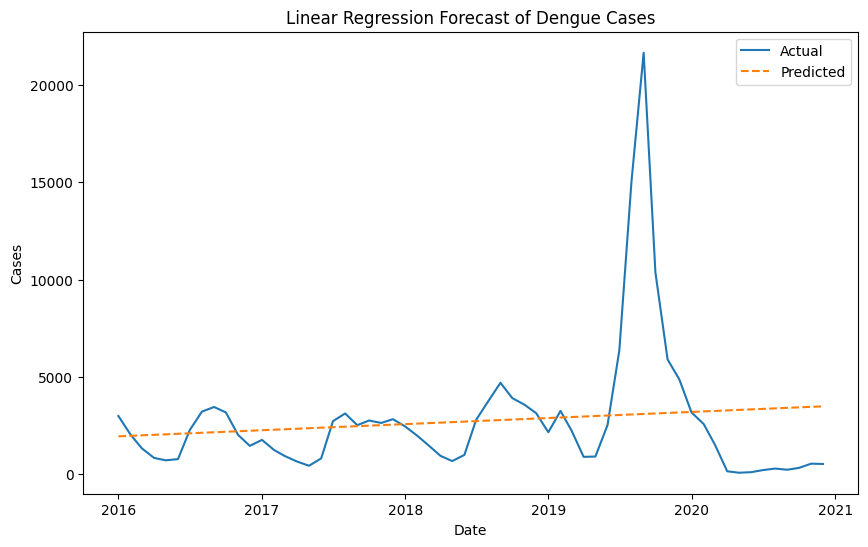

In [11]:
plt.figure(figsize=(10,6))
plt.plot(monthly_cases['Date'], monthly_cases['Dengue_Cases'], label='Actual')
plt.plot(monthly_cases['Date'], monthly_cases['Predicted_Cases'], label='Predicted', linestyle='--')
plt.legend()
plt.title('Linear Regression Forecast of Dengue Cases')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.show()

In [12]:
dengue

,Month,Year,Region,Dengue_Cases,Dengue_Deaths,Mortality Rate,Date
0,January,2016,Region I,705,1,0.141844,2016-01-01
840,January,2016,NCR,1261,4,0.317209,2016-01-01
780,January,2016,Region XIII,1116,6,0.537634,2016-01-01
240,January,2016,Region IV-B,203,1,0.492611,2016-01-01
120,January,2016,Region III,1976,3,0.151822,2016-01-01
...,...,...,...,...,...,...,...
119,December,2020,Region II,96,0,0.000000,2020-12-01
899,December,2020,NCR,658,4,0.607903,2020-12-01
59,December,2020,Region I,1081,1,0.092507,2020-12-01
659,December,2020,Region X,281,1,0.355872,2020-12-01


<hr>

<h2>INSIGHTS</h2>
<hr>

<h2>1. What are the top 3 regions most at risk based on combined case count and mortality rate trends?</h2>

In [13]:

region_stats = dengue.groupby("Region").agg({
    "Dengue_Cases": "sum",
    "Mortality Rate": "mean"
}).reset_index()


region_stats["Cases_Score"] = region_stats["Dengue_Cases"] / region_stats["Dengue_Cases"].max()
region_stats["Mortality_Score"] = region_stats["Mortality Rate"] / region_stats["Mortality Rate"].max()


region_stats["Risk_Score"] = (region_stats["Cases_Score"] + region_stats["Mortality_Score"]) / 2


top3_regions = region_stats.sort_values(by="Risk_Score", ascending=False).head(3)


print("Top 3 Regions Most at Risk (Based on Cases & Mortality Rate):")
display(top3_regions[["Region", "Dengue_Cases", "Mortality Rate", "Risk_Score"]])


Top 3 Regions Most at Risk (Based on Cases & Mortality Rate):


,Region,Dengue_Cases,Mortality Rate,Risk_Score
2,NCR,115966,9.412707,0.855661
16,Region XIII,35293,9.369061,0.605923
15,Region XII,59802,7.892293,0.602645


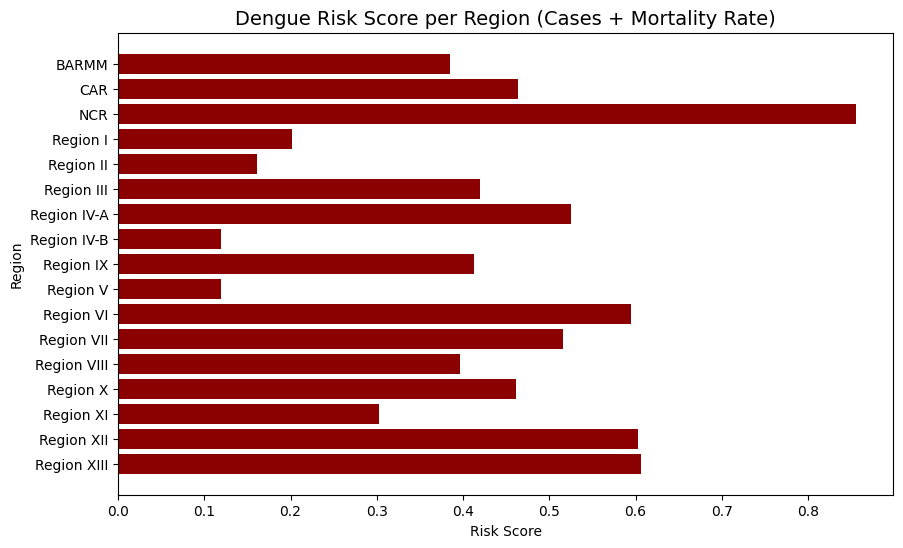

In [14]:
plt.figure(figsize=(10,6))
plt.barh(region_stats["Region"], region_stats["Risk_Score"], color='darkred')
plt.title("Dengue Risk Score per Region (Cases + Mortality Rate)", fontsize=14)
plt.xlabel("Risk Score")
plt.ylabel("Region")
plt.gca().invert_yaxis()
plt.show()

<h2>Insight No. 1</h2>
<p>In comparison to all other regions, the National Capital Region (NCR) has the highest dengue risk score.  This suggests that the NCR has a comparatively high death rate in addition to reporting a high number of dengue cases.  This pattern is probably influenced by a mix of significant population movement, stagnant water supplies, and urban congestion.  This implies that in areas with high levels of urbanization, dengue surveillance and control measures need to be strengthened.</p>
<hr>

<h2>Insight No. 2</h2>
<p>Dengue is not limited to metropolitan areas; it also affects provincial and island regions, as evidenced by the relatively high risk scores displayed by regions like Region VI, Region VII, Region XII, and Region XIII.  These regions may be at risk during outbreaks due to inadequate healthcare infrastructure or inconsistent vector control initiatives.</p>
<hr>

<h2>2. During which months do dengue cases typically peak nationwide?</h2>

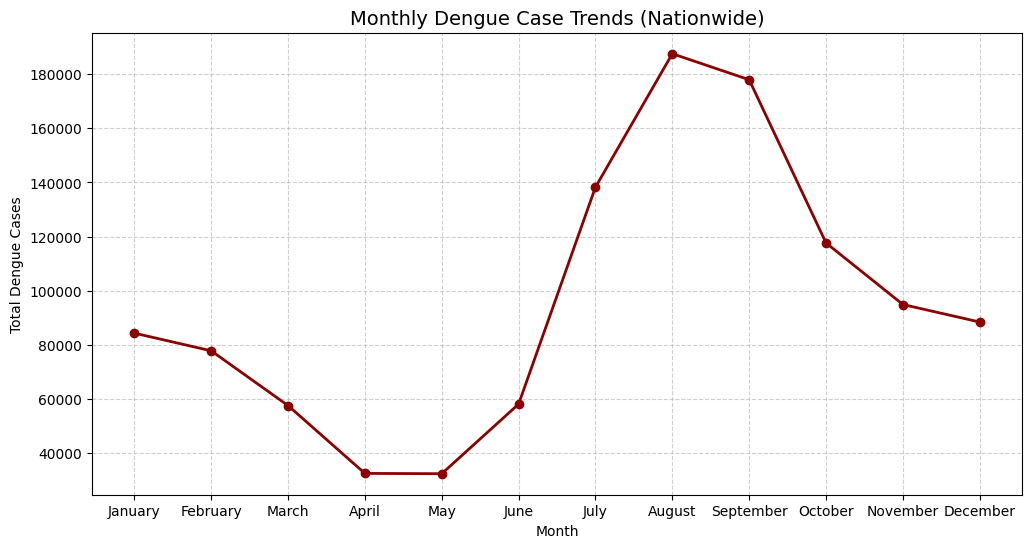

Months with Highest Dengue Cases:


,Month,Dengue_Cases
1,August,187554
11,September,177943
5,July,138242


In [15]:

monthly_cases = dengue.groupby("Month")["Dengue_Cases"].sum().reset_index()


month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

monthly_cases["Month"] = pd.Categorical(monthly_cases["Month"], categories=month_order, ordered=True)
monthly_cases = monthly_cases.sort_values("Month")

plt.figure(figsize=(12,6))
plt.plot(monthly_cases["Month"], monthly_cases["Dengue_Cases"], marker='o', color='darkred', linewidth=2)
plt.title("Monthly Dengue Case Trends (Nationwide)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Dengue Cases")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# Identify peak months
peak_months = monthly_cases.sort_values(by="Dengue_Cases", ascending=False).head(3)
print("Months with Highest Dengue Cases:")
display(peak_months)


<h2>Insight No. 3</h2>
<p>The study indicates that dengue cases increase significantly starting in June, peaking in August, and subsequently declining by October. This correlates with the rainy season in the Philippines, during which stagnant water becomes prevalent, creating ideal conditions for mosquito breeding.</p>
<hr>

<h2>Insight No. 4</h2>
<p>The months of April and May saw the fewest dengue cases across the country. This period usually aligns with the dry season, during which decreased rainfall minimizes areas for mosquito breeding.</p>
<hr>

<h2>3. Which region has the highest average dengue cases throughout 2016–2020?</h2>

In [16]:
region_avg_cases = dengue.groupby("Region")["Dengue_Cases"].mean().reset_index()
region_avg_cases = region_avg_cases.sort_values(by="Dengue_Cases", ascending=False)

In [17]:
print("Average Dengue Cases per Region (2016–2020):")
display(region_avg_cases)

Average Dengue Cases per Region (2016–2020):


,Region,Dengue_Cases
6,Region IV-A,2717.150000
5,Region III,2184.400000
10,Region VI,1958.716667
2,NCR,1932.766667
11,Region VII,1844.716667
13,Region X,1373.950000
15,Region XII,996.700000
3,Region I,984.433333
12,Region VIII,866.383333
8,Region IX,796.350000


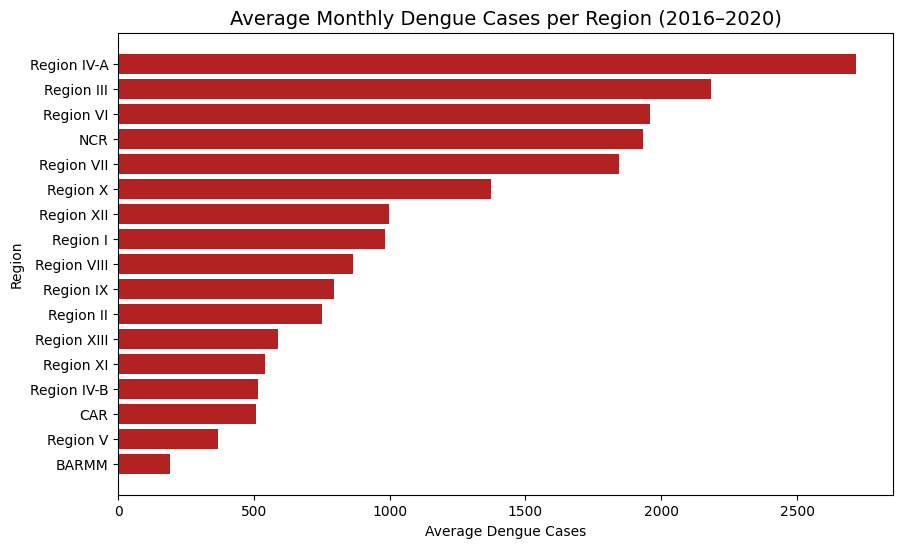

In [18]:
plt.figure(figsize=(10,6))
plt.barh(region_avg_cases["Region"], region_avg_cases["Dengue_Cases"], color='firebrick')
plt.title("Average Monthly Dengue Cases per Region (2016–2020)", fontsize=14)
plt.xlabel("Average Dengue Cases")
plt.ylabel("Region")
plt.gca().invert_yaxis()
plt.show()

<h2>Insight No. 5</h2>
<p>The study shows that Region-IV-A experiences the highest average number of dengue cases between 2016 and 2020, highlighting its status as a continual hotspot for dengue transmission.</p>
<hr>

<h2>4. Which region consistently maintains a low mortality rate despite having many cases?</h2>

In [19]:
region_stats = dengue.groupby("Region").agg({
    "Dengue_Cases": "sum",
    "Mortality Rate": "mean"
}).reset_index()

avg_cases = region_stats["Dengue_Cases"].mean()
low_mortality_high_cases = region_stats[
    (region_stats["Dengue_Cases"] > avg_cases) &
    (region_stats["Mortality Rate"] < region_stats["Mortality Rate"].mean())
].sort_values(by="Mortality Rate")

print("Regions with High Dengue Cases but Low Mortality Rate:")
display(low_mortality_high_cases)


Regions with High Dengue Cases but Low Mortality Rate:


,Region,Dengue_Cases,Mortality Rate
5,Region III,131064,0.328489
6,Region IV-A,163029,0.462963
11,Region VII,110683,3.317392
13,Region X,82437,3.933678


<h2>Insight. No. 6</h2>
<p>Although Region IV-A and Region III recorded some of the highest dengue case numbers in the country, their mortality rates remained significantly lower than the national average.</p>
<hr>

<h2>5. Which year recorded the highest and lowest number of dengue cases nationwide?</h2>

Highest dengue cases recorded in: 2019 (441,902 cases)
Lowest dengue cases recorded in: 2020 (91,041 cases)


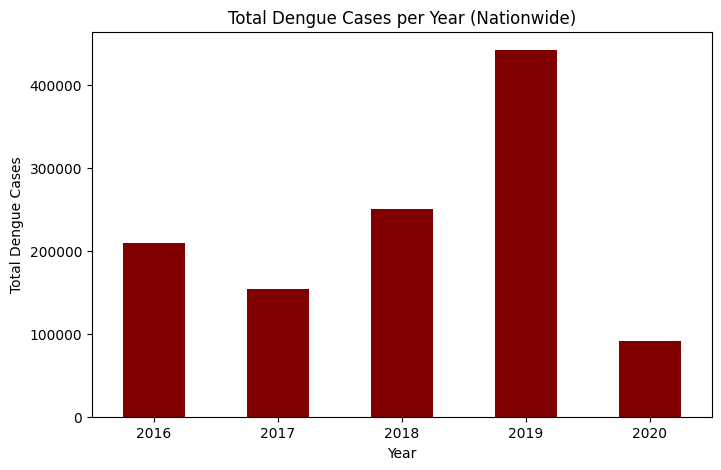

In [20]:
yearly_cases = dengue.groupby('Year')['Dengue_Cases'].sum()


highest_year = yearly_cases.idxmax()
lowest_year = yearly_cases.idxmin()

print(f"Highest dengue cases recorded in: {highest_year} ({yearly_cases[highest_year]:,.0f} cases)")
print(f"Lowest dengue cases recorded in: {lowest_year} ({yearly_cases[lowest_year]:,.0f} cases)")


plt.figure(figsize=(8,5))
yearly_cases.plot(kind='bar', color='maroon')
plt.title('Total Dengue Cases per Year (Nationwide)')
plt.xlabel('Year')
plt.ylabel('Total Dengue Cases')
plt.xticks(rotation=0)
plt.show()


<h2>Insight No. 7</h2>
<p>The data shows that 2019 recorded the highest number of dengue cases nationwide, marking a significant surge compared to previous years. This sharp increase suggests a possible outbreak or failure in preventive measures during that year.</p>
<hr>


<h2>Insight No. 8</h2>
<p>In contrast, 2020 shows a dramatic drop in dengue cases—over 70% lower than 2019 levels. This decline may be attributed to pandemic-related lockdowns, reduced mobility, and enhanced sanitation efforts, which inadvertently helped suppress mosquito breeding and dengue transmission.</p>
<hr>


<h2>6. Are there regions that experienced outbreak years (sudden spikes in cases)?</h2>

In [21]:
month_year_stats = dengue.groupby(['Year', 'Month'])[['Dengue_Cases', 'Dengue_Deaths']].sum().reset_index()


highest_cases = month_year_stats.loc[month_year_stats['Dengue_Cases'].idxmax()]
highest_deaths = month_year_stats.loc[month_year_stats['Dengue_Deaths'].idxmax()]

print(" Month-Year with the Highest Dengue Cases:")
print(f"{highest_cases['Month']} {highest_cases['Year']} - {highest_cases['Dengue_Cases']:,} cases")

print("\n Month-Year with the Highest Dengue Deaths:")
print(f"{highest_deaths['Month']} {highest_deaths['Year']} - {highest_deaths['Dengue_Deaths']:,} deaths")


display(month_year_stats.sort_values(by='Dengue_Cases', ascending=False).head(10))

 Month-Year with the Highest Dengue Cases:
September 2019 - 89,642 cases

 Month-Year with the Highest Dengue Deaths:
October 2016 - 3,954 deaths


,Year,Month,Dengue_Cases,Dengue_Deaths
47,2019,September,89642,377
37,2019,August,85038,280
41,2019,July,55220,232
46,2019,October,46382,133
35,2018,September,38617,185
1,2016,August,36195,132
25,2018,August,34210,156
26,2018,December,31353,135
29,2018,July,30363,153
33,2018,November,30191,131


<h2>Insight No. 9</h2>
<p>The data reveals that September 2019 recorded the highest number of dengue cases nationwide with 89,642 reported cases, suggesting a severe outbreak likely influenced by favorable breeding conditions for mosquitoes during the rainy season. Interestingly, the highest number of dengue-related deaths occurred earlier, in October 2016, totaling 3,954 fatalities.</p>
<hr>


<h2>Insight No. 10</h2>
<p>The data reveals that September 2019 recorded the highest number of dengue cases nationwide with 89,642 reported cases, suggesting a severe outbreak likely influenced by favorable breeding conditions for mosquitoes during the rainy season. Interestingly, the highest number of dengue-related deaths occurred earlier, in October 2016, totaling 3,954 fatalities.</p>
<hr>


<h2>7. How have total dengue cases changed from 2016 to 2020?</h2>

In [22]:
yearly_cases = dengue.groupby('Year')['Dengue_Cases'].sum().reset_index()


yearly_cases['Percent_Change'] = yearly_cases['Dengue_Cases'].pct_change() * 100

display(yearly_cases)

,Year,Dengue_Cases,Percent_Change
0,2016,209544,NaN
1,2017,154155,-26.433112
2,2018,250783,62.682365
3,2019,441902,76.208914
4,2020,91041,-79.397921


<h2>Insight No. 11</h2>
<p>The data reveals that dengue cases decreased by 26.4% in 2017 compared to 2016, followed by a strong rebound in 2018 with a 62.7% increase.</p>
<hr>

<h2>8. Can we predict the number of dengue cases based on the year?</h2>

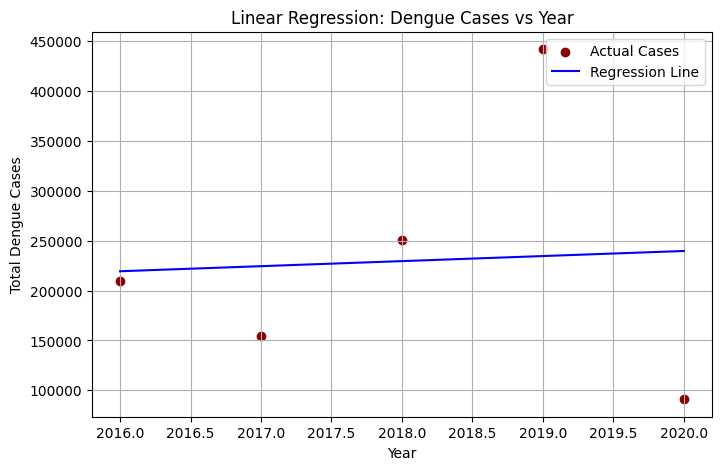

In [23]:
yearly_cases = dengue.groupby('Year')['Dengue_Cases'].sum().reset_index()


X = yearly_cases[['Year']] 
y = yearly_cases['Dengue_Cases']  

model = LinearRegression()
model.fit(X, y)


yearly_cases['Predicted_Cases'] = model.predict(X)


future_year = np.array([[2021]])
future_prediction = model.predict(future_year)[0]


plt.figure(figsize=(8,5))
plt.scatter(X, y, color='darkred', label='Actual Cases')
plt.plot(X, yearly_cases['Predicted_Cases'], color='blue', label='Regression Line')
plt.title('Linear Regression: Dengue Cases vs Year')
plt.xlabel('Year')
plt.ylabel('Total Dengue Cases')
plt.legend()
plt.grid(True)
plt.show()

<h2>Insight No. 12</h2>
<p>The linear regression model suggests a slight upward trend in dengue cases from 2016 to 2020, indicating that the overall number of cases tended to increase over time. However, the data shows significant fluctuations, such as the sharp spike in 2019 and a major decline in 2020.</p>
<hr>

<h2>9. How strongly does mortality rate depend on dengue cases?</h2>

In [24]:
X = dengue[['Dengue_Cases']]   
y = dengue['Mortality Rate']     


model = LinearRegression()
model.fit(X, y)


y_pred = model.predict(X)
print("Regression Equation:")
print(f"Mortality Rate = ({model.coef_[0]:.6f} * Dengue Cases) + {model.intercept_:.6f}")

r2 = model.score(X, y)
print(f"\nR² Score (Model Accuracy): {r2:.4f}")


Regression Equation:
Mortality Rate = (-0.001037 * Dengue Cases) + 5.179168

R² Score (Model Accuracy): 0.0076


<h2>Insight No. 13</h2>
<p>The regression analysis shows that dengue cases have a very weak relationship with the mortality rate (R² = 0.0076). This means that changes in the number of dengue cases explain less than 1% of the variation in mortality rate. The negative slope (–0.001037) indicates a slight decreasing trend, suggesting that as dengue cases increase, the mortality rate tends to decline slightly.</p>
<hr>

<h2>10. Can we predict dengue deaths based on dengue cases and mortality rate?</h2>

In [25]:
X = dengue[['Dengue_Cases', 'Mortality Rate']]   
y = dengue['Dengue_Deaths']                      


model = LinearRegression()
model.fit(X, y)


y_pred = model.predict(X)

print("Regression Equation:")
print(f"Dengue_Deaths = ({model.coef_[0]:.4f} * Dengue_Cases) + ({model.coef_[1]:.4f} * Mortality Rate) + {model.intercept_:.4f}")


r2 = model.score(X, y)
print(f"\nR² Score (Model Accuracy): {r2:.4f}")

Regression Equation:
Dengue_Deaths = (0.0057 * Dengue_Cases) + (3.3405 * Mortality Rate) + -3.2859

R² Score (Model Accuracy): 0.4670


<h2>Insight No. 14</h2>
<p>The regression model indicates a moderate relationship between dengue deaths, dengue cases, and mortality rate, with an R² score of 0.4670. This suggests that about 46.7% of the variation in dengue deaths can be explained by the number of cases and mortality rate.</p>
<hr>

<h2>11. Is there a linear relationship between dengue cases and deaths?</h2>

In [26]:
X = dengue[['Dengue_Cases']] 
y = dengue['Dengue_Deaths']    


model = LinearRegression()
model.fit(X, y)


y_pred = model.predict(X)


print("Regression Equation:")
print(f"Dengue_Deaths = ({model.coef_[0]:.6f} * Dengue_Cases) + {model.intercept_:.6f}")

r2 = model.score(X, y)
print(f"\nR² Score (Model Accuracy): {r2:.4f}")

Regression Equation:
Dengue_Deaths = (0.002221 * Dengue_Cases) + 14.015265

R² Score (Model Accuracy): 0.0015


<h2>Insight No. 15</h2>
<p>The regression analysis shows that there is no significant linear relationship between dengue cases and dengue deaths (R² = 0.0015). This means that variations in the number of dengue cases explain less than 0.2% of the changes in dengue deaths. Although the coefficient (0.002221) is positive—indicating that deaths slightly increase as cases rise—the relationship is statistically weak.</p>
<hr>